In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('SnapDeal.csv')

In [3]:
data.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,...,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,...,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,...,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,...,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,...,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [4]:
data.shape

(800, 24)

In [5]:
# TASK 1: DATA CLEANING AND PREPARATION

In [6]:
# Task 1.1: Removing duplicate or inconsistent survey responses

# Checking for duplicate rows
duplicate_rows = data.duplicated().sum()
print('Number of duplicate rows = ', duplicate_rows)

Number of duplicate rows =  0


In [7]:
# Checking for duplicate transaction ids
duplicate_id = data['transaction'].duplicated().sum()
print('Number of duplicate transactions = ', duplicate_id)

Number of duplicate transactions =  0


In [8]:
# Task 1.2: Checking for inconsistency in textual/categorical columns
cat_col = data.select_dtypes(include = 'object').columns
for i in cat_col:
  print(f'\n {i}')
  print(data[i].dropna().unique())


 Timestamp
['2023/06/07 11:06:40 PM GMT+5:30' '2023/06/06 7:08:47 PM GMT+5:30'
 '2023/06/08 9:39:30 PM GMT+5:30' '2023/06/07 9:22:24 PM GMT+5:30'
 '2023/06/06 7:21:26 PM GMT+5:30' '2023/06/04 11:27:53 PM GMT+5:30'
 '2023/06/06 7:40:53 PM GMT+5:30' '2023/06/06 5:16:58 PM GMT+5:30'
 '2023/06/08 9:39:55 PM GMT+5:30' '2023/06/11 11:10:14 PM GMT+5:30'
 '2023/06/07 10:10:58 PM GMT+5:30' '2023/06/09 9:35:57 AM GMT+5:30'
 '2023/06/09 9:33:35 AM GMT+5:30' '2023/06/08 5:15:27 PM GMT+5:30'
 '2023/06/09 8:10:05 AM GMT+5:30' '2023/06/07 11:41:56 AM GMT+5:30'
 '2023/06/08 5:27:22 PM GMT+5:30' '2023/06/04 8:00:11 PM GMT+5:30'
 '2023/06/09 2:51:07 PM GMT+5:30' '2023/06/08 5:35:01 PM GMT+5:30'
 '2023/06/08 3:23:58 AM GMT+5:30' '2023/06/06 8:56:17 PM GMT+5:30'
 '2023/06/11 11:15:03 PM GMT+5:30' '2023/06/06 6:38:45 PM GMT+5:30'
 '2023/06/09 10:23:05 AM GMT+5:30' '2023/06/11 11:20:18 PM GMT+5:30'
 '2023/06/10 2:41:51 PM GMT+5:30' '2023/06/04 10:37:00 PM GMT+5:30'
 '2023/06/08 8:26:58 PM GMT+5:30' '2023/0

In [9]:
# Removing leading & trailing spaces in categorical columns (Like Service_Appreciation)
for i in cat_col:
  data[i] = data[i].str.strip()

In [10]:
print(data['Service_Appreciation'].unique())
print(data['Improvement_Areas'].unique())

['Customer service' '.' 'Wide product selection' 'All the above'
 'User-friendly website/app interface' 'Quick delivery'
 'Competitive prices' 'Product recommendations']
['User interface of app' '.' 'Product quality and accuracy'
 "I don't have any problem with Amazon" 'Customer service responsiveness'
 'Nil' 'No problems with Amazon' 'Irrelevant product suggestions'
 'better app interface and lower shipping charges'
 'Shipping speed and reliability' 'Nothing'
 'I have no problem with Amazon yet. But others tell me about the refund issues'
 'UI' 'Quality of product is very poor according to the big offers'
 'Scrolling option would be much better than going to next page'
 'User interface' 'Reducing packaging waste'
 'Add more familiar brands to the list']


In [11]:
# Task 1.3: Handling missing values and inconsistent formats
#           in Product_Search_Method and other fields.
miss_val = data.isnull().sum()
print('Number of missing Values = ', miss_val[miss_val > 0])
# Checking the number of '.' values
dot_val = (data == '.').sum()
print('Number of dot values = ', dot_val[dot_val > 0])

Number of missing Values =  Product_Search_Method    149
dtype: int64
Number of dot values =  Service_Appreciation    89
Improvement_Areas       38
dtype: int64


In [12]:
# Converting all '.' values to nan to collectively remove
# all nan values together in the next step
import numpy as np
data = data.replace('.', np.nan)
print(data.isnull().sum()[data.isnull().sum() > 0])

Product_Search_Method    149
Service_Appreciation      89
Improvement_Areas         38
dtype: int64


In [13]:
# See the distribution of Product_Search_Method
print(data['Product_Search_Method'].value_counts(dropna=False))

Product_Search_Method
others        182
Keyword       163
categories    156
Filter        150
NaN           149
Name: count, dtype: int64


In [14]:
# Total missing values after converting '.' to nan
print("Total missing values:", data.isnull().sum().sum())
# Since it makes up 34.5% of the total data, we won't drop these

Total missing values: 276


In [15]:
# Task 1.4: Renaming duplicate or misformatted columns
#           (e.g., remove trailing spaces in Rating_Accuracy )
print(data.columns.tolist())

['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [16]:
# Since there are 2 columns with the same names
print(data['Personalized_Recommendation_Frequency'].value_counts(dropna=False))
print(data['Personalized_Recommendation_Frequency '].value_counts(dropna=False))

Personalized_Recommendation_Frequency
No           285
Sometimes    272
Yes          243
Name: count, dtype: int64
Personalized_Recommendation_Frequency 
1    173
2    166
3    163
4    155
5    143
Name: count, dtype: int64


In [17]:
print(data['Rating_Accuracy '].value_counts(dropna=False))

Rating_Accuracy 
2    169
1    167
4    160
5    157
3    147
Name: count, dtype: int64


In [18]:
# Renaming the 2nd same name column
# and removing trailing space in Rating_Accuracy
data = data.rename(columns = {'Personalized_Recommendation_Frequency ':
                              'Personalized_Recommendation_Frequency_Rating',
                              'Rating_Accuracy ': 'Rating_Accuracy'})

In [19]:
print(data.columns.tolist())

['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency_Rating', 'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [20]:
# Task 1.5: Convert numerical rating columns
#           (e.g., Customer_Reviews_Importance, Shopping_Satisfaction)
#           to appropriate numeric types for analysis

# Finding the numeric rating columns
rate_col = ['Customer_Reviews_Importance', 'Personalized_Recommendation_Frequency_Rating',
            'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Review_Helpfulness']
print(data[rate_col].dtypes)

Customer_Reviews_Importance                      int64
Personalized_Recommendation_Frequency_Rating     int64
Recommendation_Helpfulness                      object
Rating_Accuracy                                  int64
Shopping_Satisfaction                            int64
Review_Helpfulness                              object
dtype: object


In [21]:
# Validating that all numeric rating columns are integers
rate_col = ['Customer_Reviews_Importance',
            'Personalized_Recommendation_Frequency_Rating',
            'Rating_Accuracy','Shopping_Satisfaction']
for i in rate_col:
    print(f"{i}:")
    print("Data type:", data[i].dtype)
    print("Unique values:", sorted(data[i].dropna().unique()))
    print()

Customer_Reviews_Importance:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Personalized_Recommendation_Frequency_Rating:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rating_Accuracy:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Shopping_Satisfaction:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]



In [22]:
# TASK 2: DESCRIPTIVE BEHAVIOUR ANALYSIS

# Task 2.1: Summarizing customer demographics (age, gender distribution)
print('Age Statistics')
print(data['age'].describe())
print('Gender Statistics')
print(data['Gender'].describe())
print('Gender %')
print(data['Gender'].value_counts(normalize = True) * 100)

Age Statistics
count    800.000000
mean      36.053750
std       19.310087
min        3.000000
25%       18.000000
50%       37.000000
75%       53.000000
max       67.000000
Name: age, dtype: float64
Gender Statistics
count      800
unique       4
top       Male
freq       213
Name: Gender, dtype: object
Gender %
Gender
Male                 26.625
Female               25.125
Prefer not to say    24.250
Others               24.000
Name: proportion, dtype: float64


In [23]:
# Therefore, the middle 50% age groups are from 18-53
# The largest gender group is Male (26.625%) but does not
# differ significantly from other genders.

In [24]:
# Task 2.2: Analyzing overall purchase frequency
#           and most popular product categories
print('Purchase Frequency')
print(data['Purchase_Frequency'].value_counts())
print('Purchase Frequency %')
print(data['Purchase_Frequency'].value_counts(normalize = True)*100)
print('Purchase Categories')
print(data['Purchase_Categories'].value_counts().head(5))

Purchase Frequency
Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64
Purchase Frequency %
Purchase_Frequency
Multiple times a week     20.750
Once a month              20.500
Once a week               20.125
Few times a month         19.625
Less than once a month    19.000
Name: proportion, dtype: float64
Purchase Categories
Purchase_Categories
Clothing and Fashion                                                                         36
Clothing and Fashion;Home and Kitchen                                                        34
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion                     34
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen    32
others                                                                                       32
Name: count, dtype: int64


In [25]:
# Individual Categories Count and Percentage of respondents
# who selected each category
cat_count = data['Purchase_Categories'].dropna().str.split(';').explode().str.strip().value_counts()
cat_percent = cat_count/len(data) * 100
print(cat_count)
print(cat_percent)

Purchase_Categories
Clothing and Fashion          476
Beauty and Personal Care      414
Home and Kitchen              405
others                        396
Groceries and Gourmet Food    381
Name: count, dtype: int64
Purchase_Categories
Clothing and Fashion          59.500
Beauty and Personal Care      51.750
Home and Kitchen              50.625
others                        49.500
Groceries and Gourmet Food    47.625
Name: count, dtype: float64


In [26]:
# Task 2.3: Identifying top browsing methods
#           and most common cart abandonment factors

# Analyzing Browsing Frequency Firstly
print('Browsing Frequency')
print(data['Browsing_Frequency'].value_counts())
print('Browsing Frequency %')
print(data['Browsing_Frequency'].value_counts(normalize = True)*100)

Browsing Frequency
Browsing_Frequency
Multiple times a day    204
Few times a week        202
Few times a month       199
Rarely                  195
Name: count, dtype: int64
Browsing Frequency %
Browsing_Frequency
Multiple times a day    25.500
Few times a week        25.250
Few times a month       24.875
Rarely                  24.375
Name: proportion, dtype: float64


In [27]:
# Analyzing Product Search Methods
print('Product Search Method')
print(data['Product_Search_Method'].value_counts(dropna = False))
print('Product Search Method %')
print(data['Product_Search_Method'].value_counts(normalize = True, dropna = False)*100)

Product Search Method
Product_Search_Method
others        182
Keyword       163
categories    156
Filter        150
NaN           149
Name: count, dtype: int64
Product Search Method %
Product_Search_Method
others        22.750
Keyword       20.375
categories    19.500
Filter        18.750
NaN           18.625
Name: proportion, dtype: float64


In [28]:
# Analyzing Search Result Exploration
print('Search Result Exploration')
print(data['Search_Result_Exploration'].value_counts())
print('Search Result Exploration %')
print(data['Search_Result_Exploration'].value_counts(normalize = True)*100)

Search Result Exploration
Search_Result_Exploration
Multiple pages    416
First page        384
Name: count, dtype: int64
Search Result Exploration %
Search_Result_Exploration
Multiple pages    52.0
First page        48.0
Name: proportion, dtype: float64


In [29]:
# Analyzing Add to Cart Browsing
print('Add to Cart Browsing')
print(data['Add_to_Cart_Browsing'].value_counts())
print('Add to Cart Browsing %')
print(data['Add_to_Cart_Browsing'].value_counts(normalize = True)*100)

Add to Cart Browsing
Add_to_Cart_Browsing
Yes      276
No       265
Maybe    259
Name: count, dtype: int64
Add to Cart Browsing %
Add_to_Cart_Browsing
Yes      34.500
No       33.125
Maybe    32.375
Name: proportion, dtype: float64


In [30]:
# Analyzing Cart Completion Frequency
print('Cart Completion Frequency')
print(data['Cart_Completion_Frequency'].value_counts())
print('Cart Completion Frequency %')
print(data['Cart_Completion_Frequency'].value_counts(normalize = True)*100)

Cart Completion Frequency
Cart_Completion_Frequency
Often        173
Always       166
Sometimes    158
Never        157
Rarely       146
Name: count, dtype: int64
Cart Completion Frequency %
Cart_Completion_Frequency
Often        21.625
Always       20.750
Sometimes    19.750
Never        19.625
Rarely       18.250
Name: proportion, dtype: float64


In [31]:
# Analyzing Cart Abandoment Factors
print('Cart Abandonment Factors')
print(data['Cart_Abandonment_Factors'].value_counts())
print('Cart Abandonment Factors %')
print(data['Cart_Abandonment_Factors'].value_counts(normalize = True)*100)

Cart Abandonment Factors
Cart_Abandonment_Factors
Found a better price elsewhere                219
others                                        196
High shipping costs                           194
Changed my mind or no longer need the item    191
Name: count, dtype: int64
Cart Abandonment Factors %
Cart_Abandonment_Factors
Found a better price elsewhere                27.375
others                                        24.500
High shipping costs                           24.250
Changed my mind or no longer need the item    23.875
Name: proportion, dtype: float64


In [32]:
# Task 2.4: Calculating mean and median satisfaction,
#           recommendation helpfulness, and rating accuracy
print('Shopping Satisfaction')
print(data['Shopping_Satisfaction'].describe())
print('Rating Accuracy')
print(data['Rating_Accuracy'].describe())
print('Recommendation Helpfulness')
print(data['Recommendation_Helpfulness'].value_counts(normalize = True)*100)
print("Personalized Recommendation Frequency Rating:")
print(data['Personalized_Recommendation_Frequency_Rating'].describe())

Shopping Satisfaction
count    800.000000
mean       2.988750
std        1.407515
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Shopping_Satisfaction, dtype: float64
Rating Accuracy
count    800.00000
mean       2.96375
std        1.42565
min        1.00000
25%        2.00000
50%        3.00000
75%        4.00000
max        5.00000
Name: Rating_Accuracy, dtype: float64
Recommendation Helpfulness
Recommendation_Helpfulness
No           36.875
Yes          32.625
Sometimes    30.500
Name: proportion, dtype: float64
Personalized Recommendation Frequency Rating:
count    800.000000
mean       2.911250
std        1.405647
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Personalized_Recommendation_Frequency_Rating, dtype: float64


In [33]:
# Task 2.5: Generating summary statistics and visualizations for key behavioral variables.
summary = data[['Shopping_Satisfaction', 'Rating_Accuracy',
                'Personalized_Recommendation_Frequency_Rating']].agg(
                    ['mean', 'median', 'std', 'min', 'max']).T
print(summary)

                                                 mean  median       std  min  \
Shopping_Satisfaction                         2.98875     3.0  1.407515  1.0   
Rating_Accuracy                               2.96375     3.0  1.425650  1.0   
Personalized_Recommendation_Frequency_Rating  2.91125     3.0  1.405647  1.0   

                                              max  
Shopping_Satisfaction                         5.0  
Rating_Accuracy                               5.0  
Personalized_Recommendation_Frequency_Rating  5.0  


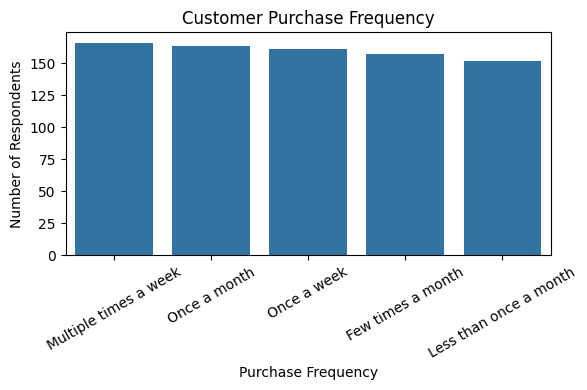

In [34]:
# Visualizations
# 1) Purchasing Frequency
plt.figure(figsize = (6, 4))
sns.countplot(data = data, x = 'Purchase_Frequency',
              order = data['Purchase_Frequency'].value_counts().index)
plt.title('Customer Purchase Frequency')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Respondents')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

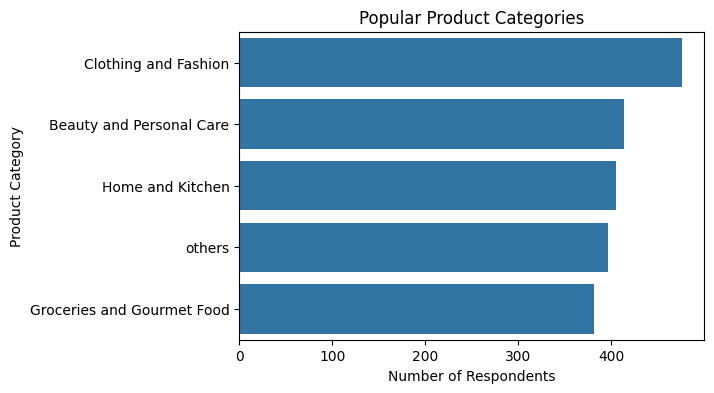

In [35]:
# 2) Individual Purchase Categories using cat_count
plt.figure(figsize = (6, 4))
sns.barplot(x = cat_count.values, y = cat_count.index)
plt.title('Popular Product Categories')
plt.xlabel('Number of Respondents')
plt.ylabel('Product Category')
plt.show()

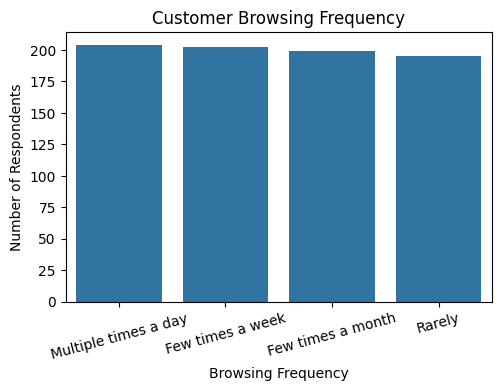

In [36]:
# 3) Browsing Frequency
plt.figure(figsize = (5.5, 3.5))
sns.countplot(data = data, x = 'Browsing_Frequency',
              order = data['Browsing_Frequency'].value_counts().index)
plt.title('Customer Browsing Frequency')
plt.xlabel('Browsing Frequency')
plt.ylabel('Number of Respondents')
plt.xticks(rotation = 15)

plt.show()

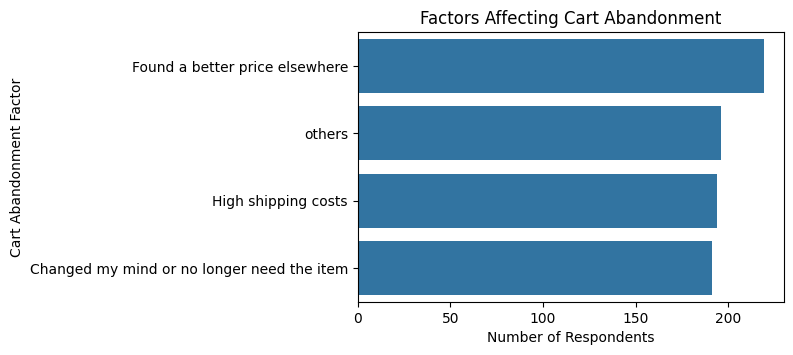

In [37]:
# 4) Cart Abandonment Factors
plt.figure(figsize = (5.5, 3.5))
sns.barplot(x = data['Cart_Abandonment_Factors'].value_counts().values,
            y = data['Cart_Abandonment_Factors'].value_counts().index)
plt.title('Factors Affecting Cart Abandonment')
plt.xlabel('Number of Respondents')
plt.ylabel('Cart Abandonment Factor')
plt.show()

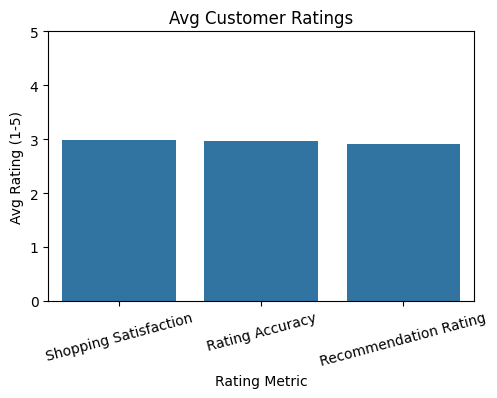

In [38]:
# 5) Key Rating Metrics
rating_mean = data[['Shopping_Satisfaction', 'Rating_Accuracy',
                    'Personalized_Recommendation_Frequency_Rating']].mean()
rating_mean.index = ['Shopping Satisfaction', 'Rating Accuracy',
                     'Recommendation Rating']
plt.figure(figsize = (5.5, 3.5))
sns.barplot(x = rating_mean.index, y = rating_mean.values)
plt.title('Avg Customer Ratings')
plt.xlabel('Rating Metric')
plt.ylabel('Avg Rating (1-5)')
plt.ylim(0, 5)
plt.xticks(rotation = 15)
plt.show()

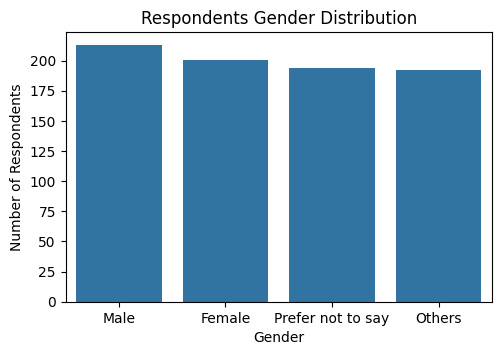

In [39]:
# 6) Gender Distribution
plt.figure(figsize = (5.5, 3.5))
sns.countplot(data = data, x = 'Gender',
              order = data['Gender'].value_counts().index)
plt.title('Respondents Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.show()

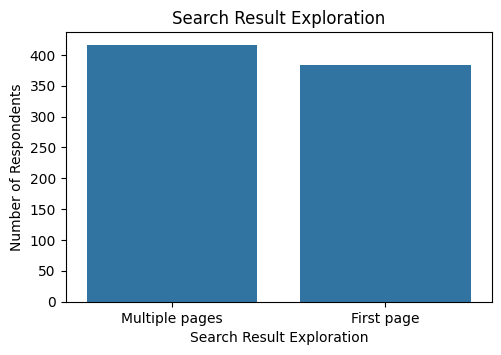

In [40]:
# 7) Search Result Exploration
plt.figure(figsize = (5.5, 3.5))
sns.countplot(data = data, x = 'Search_Result_Exploration',
              order = data['Search_Result_Exploration'].value_counts().index)
plt.title('Search Result Exploration')
plt.xlabel('Search Result Exploration')
plt.ylabel('Number of Respondents')
plt.show()

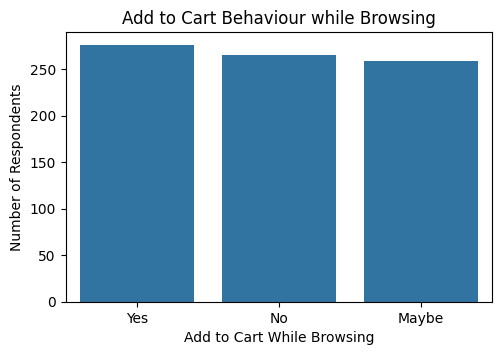

In [41]:
# 8) Add to Cart Browsing
plt.figure(figsize = (5.5, 3.5))
sns.countplot(data = data, x = 'Add_to_Cart_Browsing',
              order = data['Add_to_Cart_Browsing'].value_counts().index)
plt.title('Add to Cart Behaviour while Browsing')
plt.xlabel('Add to Cart While Browsing')
plt.ylabel('Number of Respondents')
plt.show()

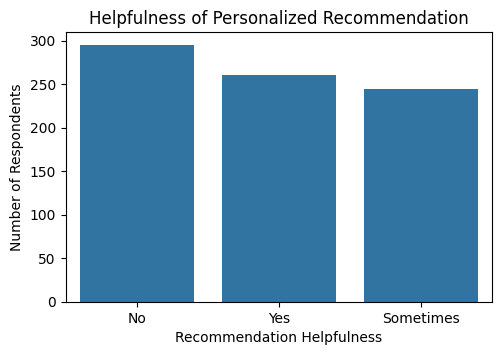

In [42]:
# 9) Recommendation Helpfulness
plt.figure(figsize = (5.5, 3.5))
sns.countplot(data = data, x = 'Recommendation_Helpfulness',
              order = data['Recommendation_Helpfulness'].value_counts().index)
plt.title('Helpfulness of Personalized Recommendation')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Number of Respondents')
plt.show()

In [43]:
# TASK 3: CUSTOMER SEGMENTATION AND PROFILING

# Task 3.1: Segmenting customers based on purchase frequency
#         & shopping satisfaction levels

# Task 3.2: Create profiles such as:
# Frequent Buyers: High purchase frequency, high satisfaction
# Occasional Shoppers: Medium frequency, moderate satisfaction
# At-Risk Customers: Low satisfaction or frequent cart abandonment
segment_table = pd.crosstab(data['Purchase_Frequency'],
                            data['Shopping_Satisfaction'])
print(segment_table)

Shopping_Satisfaction    1   2   3   4   5
Purchase_Frequency                        
Few times a month       36  31  36  25  29
Less than once a month  21  30  36  32  33
Multiple times a week   33  36  35  26  36
Once a month            36  35  37  26  30
Once a week             30  32  33  30  36


In [44]:
# Purchase Frequency Segmentation
# Multiple times a week or Once a week: High frequency
# Few times a month or once a month: Medium frequency
# Less than once a month: Low frequency

# Shopping Satisfaction Segmentation
# 1-2 Rating: Low satisfaction
# 3: Medium satisfaction
# 4-5: High satisfaction

In [45]:
# Creating both columns
data['Purchase_Frequency_Segment'] = data['Purchase_Frequency'].map({
    'Multiple times a week': 'High Frequency',
    'Once a week': 'High Frequency',
    'Few times a month': 'Medium Frequency',
    'Once a month': 'Medium Frequency',
    'Less than once a month': 'Low Frequency'
    })
data['Satisfaction_Segment'] = pd.cut(
    data['Shopping_Satisfaction'],
    bins = [0,2,3,5],
    labels = ['Low Satisfaction', 'Medium Satisfaction', 'High Satisfaction'])
print(data[['Purchase_Frequency', 'Purchase_Frequency_Segment',
            'Shopping_Satisfaction', 'Satisfaction_Segment']].head(10))

      Purchase_Frequency Purchase_Frequency_Segment  Shopping_Satisfaction  \
0            Once a week             High Frequency                      3   
1           Once a month           Medium Frequency                      2   
2  Multiple times a week             High Frequency                      3   
3      Few times a month           Medium Frequency                      5   
4           Once a month           Medium Frequency                      1   
5  Multiple times a week             High Frequency                      4   
6           Once a month           Medium Frequency                      2   
7            Once a week             High Frequency                      2   
8           Once a month           Medium Frequency                      2   
9            Once a week             High Frequency                      3   

  Satisfaction_Segment  
0  Medium Satisfaction  
1     Low Satisfaction  
2  Medium Satisfaction  
3    High Satisfaction  
4     Low Satisf

In [46]:
# Checking the segment distribution
print(data['Purchase_Frequency_Segment'].value_counts())
print('Purchase Frequency Segment %')
print(data['Purchase_Frequency_Segment'].value_counts(normalize = True)*100)
print(data['Satisfaction_Segment'].value_counts())
print('Satisfaction Segment %')
print(data['Satisfaction_Segment'].value_counts(normalize = True)*100)

Purchase_Frequency_Segment
High Frequency      327
Medium Frequency    321
Low Frequency       152
Name: count, dtype: int64
Purchase Frequency Segment %
Purchase_Frequency_Segment
High Frequency      40.875
Medium Frequency    40.125
Low Frequency       19.000
Name: proportion, dtype: float64
Satisfaction_Segment
Low Satisfaction       320
High Satisfaction      303
Medium Satisfaction    177
Name: count, dtype: int64
Satisfaction Segment %
Satisfaction_Segment
Low Satisfaction       40.000
High Satisfaction      37.875
Medium Satisfaction    22.125
Name: proportion, dtype: float64


In [47]:
# Combining all the 6 segments to get total 9 combinations
data['Cust_Segment'] = data['Purchase_Frequency_Segment']+'-'+data['Satisfaction_Segment'].astype(str)
print(data['Cust_Segment'].value_counts())

Cust_Segment
Medium Frequency-Low Satisfaction       138
High Frequency-Low Satisfaction         131
High Frequency-High Satisfaction        128
Medium Frequency-High Satisfaction      110
Medium Frequency-Medium Satisfaction     73
High Frequency-Medium Satisfaction       68
Low Frequency-High Satisfaction          65
Low Frequency-Low Satisfaction           51
Low Frequency-Medium Satisfaction        36
Name: count, dtype: int64


In [48]:
# Percentage Segmentation
segment_summary = pd.DataFrame({'Count': data['Cust_Segment'].value_counts(),
                                'Percentage': data['Cust_Segment'].value_counts
                                 (normalize=True) * 100}).sort_values('Count',
                                                                      ascending = True)
print(segment_summary)


                                      Count  Percentage
Cust_Segment                                           
Low Frequency-Medium Satisfaction        36       4.500
Low Frequency-Low Satisfaction           51       6.375
Low Frequency-High Satisfaction          65       8.125
High Frequency-Medium Satisfaction       68       8.500
Medium Frequency-Medium Satisfaction     73       9.125
Medium Frequency-High Satisfaction      110      13.750
High Frequency-High Satisfaction        128      16.000
High Frequency-Low Satisfaction         131      16.375
Medium Frequency-Low Satisfaction       138      17.250


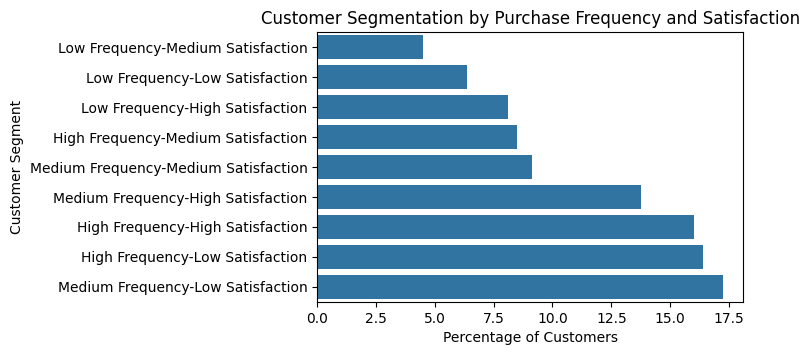

In [49]:
plt.figure(figsize=(5.5, 3.5))
sns.barplot(x = segment_summary['Percentage'], y = segment_summary.index)
plt.title('Customer Segmentation by Purchase Frequency and Satisfaction')
plt.xlabel('Percentage of Customers')
plt.ylabel('Customer Segment')
plt.show()

In [50]:
# Task 3.2: Create profiles such as:
# Frequent Buyers: High purchase frequency, high satisfaction
# Occasional Shoppers: Medium frequency, moderate satisfaction
# At-Risk Customers: Low satisfaction or frequent cart abandonment
frequent_buyers = data[(data['Purchase_Frequency_Segment'] == 'High Frequency')&
                       (data['Satisfaction_Segment'] == 'High Satisfaction')]
occasional_shoppers = data[(data['Purchase_Frequency_Segment'] == 'Medium Frequency')&
                           (data['Satisfaction_Segment'] == 'Medium Satisfaction')]
at_risk = data[(data['Satisfaction_Segment'] == 'Low Satisfaction')|
               (data['Cart_Completion_Frequency'].isin(['Rarely', 'Never']))]

In [51]:
# Task 3.3: Analyzing demographic or behavioral differences across these segments
# Age wise differences across the 3 profiles
print("Average Age")
print("Frequent Buyers:", frequent_buyers['age'].mean())
print("Occasional Shoppers:", occasional_shoppers['age'].mean())
print("At-Risk Customers:", at_risk['age'].mean())
print('\n')

# Gender wise differences across the profiles
gender_profile = pd.DataFrame({
    'Frequent Buyers': frequent_buyers['Gender'].value_counts(normalize = True)*100,
    'Occasional Shoppers': occasional_shoppers['Gender'].value_counts(normalize = True)*100,
    'At-Risk Customers': at_risk['Gender'].value_counts(normalize = True)*100
}).fillna(0)
print(gender_profile)
print('\n')

# Cart completion behaviour across the profiles
cart_profile = pd.DataFrame({
    'Frequent Buyers': frequent_buyers['Cart_Completion_Frequency'].value_counts(normalize = True)*100,
    'Occasional Shoppers': occasional_shoppers['Cart_Completion_Frequency'].value_counts(normalize = True)*100,
    'At-Risk Customers': at_risk['Cart_Completion_Frequency'].value_counts(normalize = True)*100})
print(cart_profile)

Average Age
Frequent Buyers: 35.984375
Occasional Shoppers: 37.57534246575342
At-Risk Customers: 35.662


                   Frequent Buyers  Occasional Shoppers  At-Risk Customers
Gender                                                                    
Female                    21.09375            26.027397               25.2
Male                      28.12500            34.246575               25.0
Others                    27.34375            19.178082               24.6
Prefer not to say         23.43750            20.547945               25.2


                           Frequent Buyers  Occasional Shoppers  \
Cart_Completion_Frequency                                         
Always                            23.43750            19.178082   
Never                             21.87500            23.287671   
Often                             19.53125            24.657534   
Rarely                            18.75000            20.547945   
Sometimes                         16.406

In [52]:
cart_profile

,Frequent Buyers,Occasional Shoppers,At-Risk Customers
Cart_Completion_Frequency,,,
Always,23.43750,19.178082,14.4
Never,21.87500,23.287671,31.4
Often,19.53125,24.657534,11.4
Rarely,18.75000,20.547945,29.2
Sometimes,16.40625,12.328767,13.6


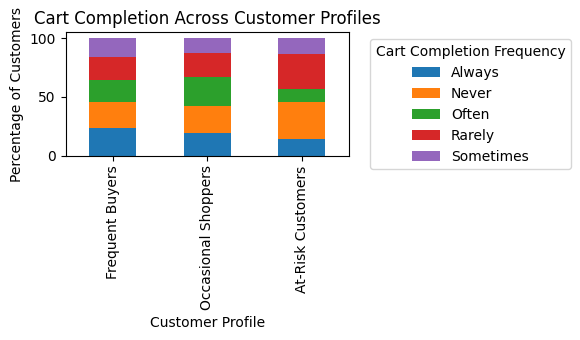

In [53]:
cart_profile.T.plot(kind='bar', stacked=True, figsize=(6, 3.5))
plt.title('Cart Completion Across Customer Profiles')
plt.xlabel('Customer Profile')
plt.ylabel('Percentage of Customers')
plt.legend(title='Cart Completion Frequency', bbox_to_anchor=(1.05, 1),
           loc='upper left')
plt.tight_layout()
plt.show()

In [54]:
# Task 3.4: Using clustering (e.g. K-Means) for behavioral grouping
#           based on survey responses
clust_col = ['Purchase_Frequency','Browsing_Frequency','Product_Search_Method',
             'Search_Result_Exploration','Add_to_Cart_Browsing','Cart_Completion_Frequency',
             'Saveforlater_Frequency','Recommendation_Helpfulness','Review_Left',
             'Review_Reliability','Review_Helpfulness','Customer_Reviews_Importance',
             'Personalized_Recommendation_Frequency_Rating','Rating_Accuracy',
             'Shopping_Satisfaction']

for i in clust_col:
    print(f"\n{i}:")
    print(data[i].value_counts(dropna=False))


Purchase_Frequency:
Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64

Browsing_Frequency:
Browsing_Frequency
Multiple times a day    204
Few times a week        202
Few times a month       199
Rarely                  195
Name: count, dtype: int64

Product_Search_Method:
Product_Search_Method
others        182
Keyword       163
categories    156
Filter        150
NaN           149
Name: count, dtype: int64

Search_Result_Exploration:
Search_Result_Exploration
Multiple pages    416
First page        384
Name: count, dtype: int64

Add_to_Cart_Browsing:
Add_to_Cart_Browsing
Yes      276
No       265
Maybe    259
Name: count, dtype: int64

Cart_Completion_Frequency:
Cart_Completion_Frequency
Often        173
Always       166
Sometimes    158
Never        157
Rarely       146
Name: count, dtype: int64

Saveforlater_Frequency:
Saveforlater_Frequenc

In [55]:
clust_data = data[clust_col].copy()
# Treating missing product search method value as Missing
clust_data['Product_Search_Method'] = (
    clust_data['Product_Search_Method'].fillna('Missing'))
print(clust_data.shape)
print(clust_data.isnull().sum())

(800, 15)
Purchase_Frequency                              0
Browsing_Frequency                              0
Product_Search_Method                           0
Search_Result_Exploration                       0
Add_to_Cart_Browsing                            0
Cart_Completion_Frequency                       0
Saveforlater_Frequency                          0
Recommendation_Helpfulness                      0
Review_Left                                     0
Review_Reliability                              0
Review_Helpfulness                              0
Customer_Reviews_Importance                     0
Personalized_Recommendation_Frequency_Rating    0
Rating_Accuracy                                 0
Shopping_Satisfaction                           0
dtype: int64


In [56]:
# Setting up Ordinal (Categories with rank/order), Nominal (No specific order)
# and Numeric columns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ordinal_col = ['Purchase_Frequency','Browsing_Frequency','Search_Result_Exploration',
               'Add_to_Cart_Browsing','Cart_Completion_Frequency','Saveforlater_Frequency',
               'Recommendation_Helpfulness','Review_Left','Review_Reliability',
               'Review_Helpfulness']
nominal_col = ['Product_Search_Method']
numeric_col = ['Customer_Reviews_Importance','Personalized_Recommendation_Frequency_Rating',
               'Rating_Accuracy','Shopping_Satisfaction']

In [57]:
ordinal_cat = [['Less than once a month', 'Once a month', 'Few times a month',
                'Once a week', 'Multiple times a week'],
                 ['Rarely', 'Few times a month', 'Few times a week',
                  'Multiple times a day'],
               ['First page', 'Multiple pages'], ['No', 'Maybe', 'Yes'],
               ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
               ['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
               ['No', 'Sometimes', 'Yes'], ['No', 'Yes'],
               ['Never', 'Rarely', 'Occasionally', 'Moderately', 'Heavily'],
               ['No', 'Sometimes', 'Yes']]
og_encoder = OrdinalEncoder(categories = ordinal_cat)
encoded_ordinal = og_encoder.fit_transform(clust_data[ordinal_col])
print(encoded_ordinal.shape)

(800, 10)


In [58]:
oneh_encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoded_nominal = oneh_encoder.fit_transform(clust_data[nominal_col])
print(encoded_nominal.shape)
print(oneh_encoder.get_feature_names_out(nominal_col))

(800, 5)
['Product_Search_Method_Filter' 'Product_Search_Method_Keyword'
 'Product_Search_Method_Missing' 'Product_Search_Method_categories'
 'Product_Search_Method_others']


In [59]:
# Therefore, 10 ordinal, 5 nominal and 4 numeric features
# K means uses distances and scaling done to prevent disproportionate influence
# of any variable on clusters
import numpy as np
encoded_numeric = clust_data[numeric_col].to_numpy()
clust_matrix = np.hstack([encoded_ordinal, encoded_nominal, encoded_numeric])
print('Before Scaling = ', clust_matrix.shape)
scaler = StandardScaler()
clust_scaled = scaler.fit_transform(clust_matrix)
print('After Scaling = ', clust_scaled.shape)

Before Scaling =  (800, 19)
After Scaling =  (800, 19)


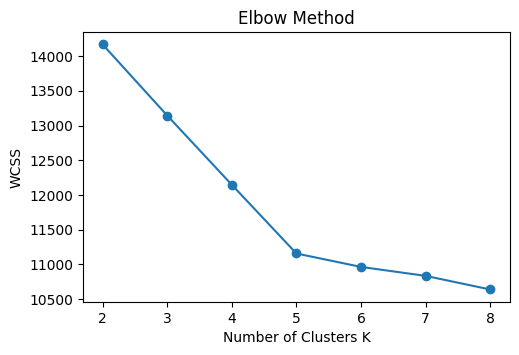

In [60]:
# Determining K (number of clusters) using Elbow method
from sklearn.cluster import KMeans
wcss = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(clust_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize = (5.5, 3.5))
plt.plot(range(2, 9), wcss, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters K')
plt.ylabel('WCSS')
plt.xticks(range(2, 9))
plt.show()

In [61]:
# Confirming K = 5 with Silhouette Score
from sklearn.metrics import silhouette_score
s_score = []
for k in range(2, 9):
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  labels = kmeans.fit_predict(clust_scaled)
  score = silhouette_score(clust_scaled, labels)
  s_score.append(score)
silhouette_summary = pd.DataFrame({'K': range(2, 9),
                                   'Silhouette Score': s_score})
print(silhouette_summary)

   K  Silhouette Score
0  2          0.065612
1  3          0.099222
2  4          0.132773
3  5          0.166573
4  6          0.132792
5  7          0.114086
6  8          0.098310


In [62]:
# Creating K-Means Model with K = 5
final_kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
data['Cluster'] = final_kmeans.fit_predict(clust_scaled)
print(data['Cluster'].value_counts().sort_index())

Cluster
0    163
1    149
2    150
3    156
4    182
Name: count, dtype: int64


In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
clust_pca = pca.fit_transform(clust_scaled)
pca_df = pd.DataFrame(clust_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data['Cluster']
print(pca_df.head())
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

        PC1       PC2  Cluster
0  0.803729  1.997723        4
1  1.144100  0.073154        3
2  2.293682 -1.392202        0
3  0.041522  1.915133        4
4 -0.535910 -0.478514        2
Explained Variance: [0.07282933 0.06970435]
Total Explained Variance: 0.1425336784844506


In [ ]:
plt.figure(figsize = (5.5, 3.5))
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', hue = 'Cluster',
                palette='tab10', s=60)
plt.title('Customer Clusters using K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [ ]:
clust_profile = data.groupby('Cluster')[['Purchase_Frequency','Browsing_Frequency',
                                         'Cart_Completion_Frequency',
                                         'Shopping_Satisfaction']].agg(lambda x: x.mode()[0])
print(clust_profile)
clust_size = data['Cluster'].value_counts().sort_index()
print("Cluster Size (%)")
print((clust_size / len(data) * 100).round(2))

In [ ]:
# Converting it to a Dataframe
clust_df = pd.DataFrame({'Purchase Frequency': clust_profile['Purchase_Frequency'],
                         'Browsing Frequency': clust_profile['Browsing_Frequency'],
                         'Cart Completion': clust_profile['Cart_Completion_Frequency'],
                         'Shopping Satisfaction': clust_profile['Shopping_Satisfaction'],
                         'Cluster Size (%)': clust_size / len(data) * 100})

In [ ]:
clust_df

In [ ]:
# TASK 4: RECOMMENDATION & REVIEW INSIGHTS

# Task 4.1: Examining the relationship between recommendation helpfulness
#           and shopping satisfaction
# Whether shopping satisfaction depends on how helpful the recommendations are
recommend_s = data.groupby('Recommendation_Helpfulness')[
    'Shopping_Satisfaction'].agg(['mean', 'median', 'count']).round(2)
print(recommend_s)

In [ ]:
plt.figure(figsize = (5.5, 3.5))
sns.barplot(data = data, x = 'Recommendation_Helpfulness',
            y = 'Shopping_Satisfaction', errorbar = None)
plt.title('Shopping Satisfaction by Recommendation Helpfulness')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Average Shopping Satisfaction')
plt.ylim(0, 5)
plt.show()

In [ ]:
# Task 4.2: Evaluating how review reliability
#           and helpfulness impact overall ratings
# How rating accuracy is affected by review reliability & helpfulness
review_rate = data.groupby(['Review_Reliability', 'Review_Helpfulness'])[
    'Rating_Accuracy'].agg(['mean', 'median', 'count']).round(2)
print(review_rate)

In [ ]:
r_heatmap = data.pivot_table(values = 'Rating_Accuracy',
                             index = 'Review_Reliability',
                             columns = 'Review_Helpfulness',
                             aggfunc = 'mean')
plt.figure(figsize = (5.5, 3.5))
sns.heatmap(r_heatmap, annot = True, fmt = '.2f')
plt.title('Rating Accuracy by Review Reliability & Helpfulness')
plt.xlabel('Review Helpfulness')
plt.ylabel('Review Reliability')
plt.show()

In [ ]:
# Task 4.3: Identifying trends in how often customers engage with or trust
#           personalized recommendations

# Personalized Recommendation Frequency Value_Counts
recommend_freq = data['Personalized_Recommendation_Frequency'].value_counts()
print(recommend_freq)
print('Percentage')
print((recommend_freq / len(data) * 100).round(2))

In [ ]:
# Personalized Recommendation Frequency Rating across recommendations
recommend_freq_rate = data.groupby('Personalized_Recommendation_Frequency')[
    'Personalized_Recommendation_Frequency_Rating'].agg(['mean',
                                                         'median', 'count']).round(2)
print(recommend_freq_rate)

In [ ]:
plt.figure(figsize = (5.5, 3.5))
sns.barplot(data = data, x = 'Personalized_Recommendation_Frequency',
            y = 'Personalized_Recommendation_Frequency_Rating',
            errorbar = None)
plt.title('Recommendation Rating by Engagement Level')
plt.xlabel('Personalized Recommendation Frequency')
plt.ylabel('Average Recommendation Rating')
plt.ylim(0, 5)
plt.show()

In [ ]:
# Task 4.4: Suggesting actionable insights for improving
#           Snapdeal’s recommendation system

# a) 35.62% of customers do not engage with personalized recommendations.
#    Use behavioral data to make recommendations more relevant.
# b) Customers engaging consistently with recommendations gave the lowest
#    average ratings of 2.77/5.
#    Review relevance and diversity of recommended products
# c) Customers for whom recommendations are less helpful have lowest
#    shopping satisfaction of 2.89/5.
#    Recommend using browsing data and other behavioral data.
# d) Recommendation strategies should be different for frequent buyers,
#    occasional shoppers and at risk customers.
# e) Track metrics like cart abandonment rate, add to cart rate,
#    customer satisfaction, cart completion frequency

In [ ]:
# TASK 5: VISUALIZATION & REPORTING

# Task 5.1: Creating visualizations for:
# Purchase categories, Browsing frequency distribution, Satisfaction levels
# Correlation between recommendation usefulness and satisfaction
# For Browsing Frequency
plt.figure(figsize = (5.5, 3.5))
plt.pie(data['Browsing_Frequency'].value_counts(),
        labels = data['Browsing_Frequency'].value_counts().index,
        autopct = '%1.1f%%', startangle = 90)
plt.title('Browsing Frequency Distribution')
plt.show()